### Import Libraries

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mnso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [58]:
data = {
    "Bedroom": [1, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 8],
    "Price":   [2500000, 3500000, 4800000, 5200000,
                7000000, 7600000, 10000000, 11500000,
                15000000, 17000000, 22000000, 30000000]
}

df = pd.DataFrame(data)

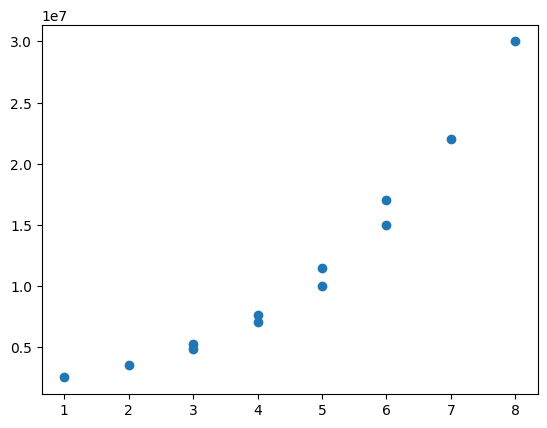

In [59]:
plt.scatter(df['Bedroom'],df['Price'])

In [60]:
X = df[['Bedroom']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [61]:
y_pred = lin_reg.predict(X_test)

[]

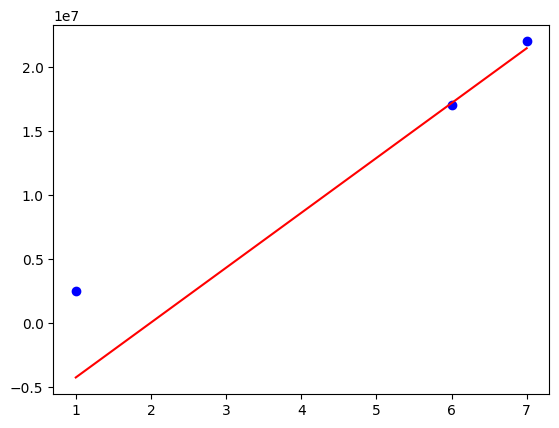

In [62]:
plt.scatter(X_test, y_test, color='blue', label='Data')
plt.plot(X_test,y_pred,color = 'red', label = 'Predict')
plt.plot()

### Transform the Features

In [63]:
poly = PolynomialFeatures(degree = 2)
X_poly = poly.fit_transform(X)

In [64]:
poly_model = LinearRegression()
poly_model.fit(X_poly,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
y_poly_pred = poly_model.predict(X_poly)

c:\Users\victo\OneDrive\Documents\Data science course\machine-learning-1\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


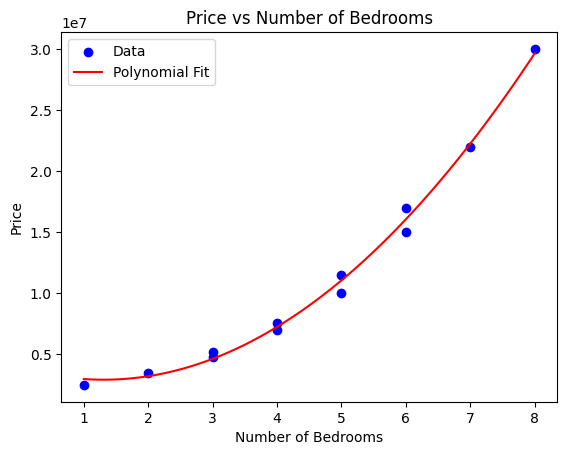

In [66]:
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_range_poly_pred = poly_model.predict(X_range_poly)

plt.scatter(X, y, color='blue', label='Data')
plt.plot(X_range, y_range_poly_pred, color='red', label='Polynomial Fit')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.title('Price vs Number of Bedrooms')
plt.legend()
plt.show()


## Example 2

### Import Libraries

In [67]:
# Data Handling and Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Preprocessing tools
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Load Data

In [68]:
df = pd.read_csv("nairobi_house_prices.csv")
df.head()

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,KSh 350 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres
1,KSh 30 000 000,Vacant Land,Karen,NaN,NaN,NaN,0.5 acres
2,KSh 325 000 000,Vacant Land,Westlands,NaN,NaN,NaN,0.5 acres
3,KSh 80 000 000,Townhouse,Kitisuru,5.0,5.0,NaN,0.5 acres
4,KSh 25 500 000,Apartment,Kileleshwa,4.0,4.0,230 m²,NaN


### Explanatory Data Analysis (EDA)

In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         204 non-null    str    
 1   propertyType  204 non-null    str    
 2   Location      204 non-null    str    
 3   Bedroom       183 non-null    float64
 4   bathroom      181 non-null    float64
 5   House size    99 non-null     str    
 6   Land size     64 non-null     str    
dtypes: float64(2), str(5)
memory usage: 11.3 KB


In [70]:
df['Price'].unique()

<StringArray>
['KSh 350 000 000',  'KSh 30 000 000', 'KSh 325 000 000',  'KSh 80 000 000',
  'KSh 25 500 000', 'KSh 300 000 000', 'KSh 160 000 000',   'KSh 9 500 000',
 'KSh 150 000 000',  'KSh 42 000 000', 'KSh 115 300 000', 'KSh 115 000 000',
  'KSh 35 000 000', 'KSh 220 000 000',   'KSh 9 000 000',   'KSh 7 200 000',
 'KSh 200 000 000',  'KSh 68 000 000',  'KSh 28 390 000',  'KSh 17 500 000',
  'KSh 18 000 000',  'KSh 38 000 000',  'KSh 78 000 000',  'KSh 75 000 000',
  'KSh 32 000 000', 'KSh 140 000 000',  'KSh 50 000 000',  'KSh 70 000 000',
  'KSh 12 000 000', 'KSh 322 550 000', 'KSh 380 000 000',   'KSh 8 700 000',
 'KSh 240 000 000',   'KSh 8 000 000',  'KSh 12 600 000',   'KSh 7 000 000',
  'KSh 18 330 000',  'KSh 20 500 000',  'KSh 16 285 499',  'KSh 12 500 000',
  'KSh 23 500 000',  'KSh 33 500 000',  'KSh 16 000 000',  'KSh 21 500 000',
  'KSh 22 500 000',  'KSh 45 000 000',  'KSh 24 000 000',  'KSh 62 500 000',
  'KSh 34 000 000',   'KSh 5 700 000',   'KSh 6 500 000',  'KS

In [71]:
df["Price"] = df["Price"].str.extract(r"(\d+)").astype(float)

In [72]:
df['Price'].unique()

array([350.,  30., 325.,  80.,  25., 300., 160.,   9., 150.,  42., 115.,
        35., 220.,   7., 200.,  68.,  28.,  17.,  18.,  38.,  78.,  75.,
        32., 140.,  50.,  70.,  12., 322., 380.,   8., 240.,  20.,  16.,
        23.,  33.,  21.,  22.,  45.,  24.,  62.,  34.,   5.,   6.,  13.,
       948., 142., 100.,  90.,  39.,  72.,  27.,  40.,  79., 110.,  29.,
        26.,  10.,  99.,  15.,  88., 143.,  95., 180., 250.,  47.,  14.,
         3.,  11.,  60., 120.])

In [73]:
df['House size'].unique()

<StringArray>
[       nan,   '230 m²',   '105 m²',   '280 m²',   '586 m²',    '90 m²',
    '70 m²',  '399 m²"',   '203 m²',   '300 m²',   '423 m²',   '283 m²',
   '385 m²',   '150 m²',    '50 m²',    '57 m²',    '65 m²',  '1 acres',
   '399 m²',   '141 m²',   '260 m²',   '186 m²',    '96 m²',   '159 m²',
    '86 m²',   '302 m²',   '160 m²',   '139 m²',   '202 m²',   '125 m²',
   '223 m²',   '445 m²',   '338 m²',    '48 m²',   '101 m²',   '800 m²',
    '61 m²',        '1',   '168 m²',   '400 m²',   '130 m²',   '116 m²',
   '190 m²',   '600 m²',   '200 m²',    '54 m²',   '110 m²',   '165 m²',
    '60 m²',    '64 m²',    '85 m²',    '75 m²', '2 025 m²',    '95 m²',
   '234 m²']
Length: 55, dtype: str

In [74]:
df["House size"] = df["House size"].astype(str).str.extract(r"(\d+)").astype(float)

In [75]:
df["Land size"] = df["Land size"].astype(str).str.extract(r"(\d+)").astype(float)

In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         204 non-null    float64
 1   propertyType  204 non-null    str    
 2   Location      204 non-null    str    
 3   Bedroom       183 non-null    float64
 4   bathroom      181 non-null    float64
 5   House size    99 non-null     float64
 6   Land size     64 non-null     float64
dtypes: float64(5), str(2)
memory usage: 11.3 KB


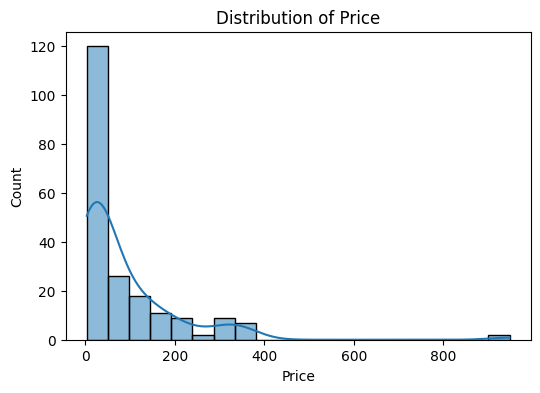

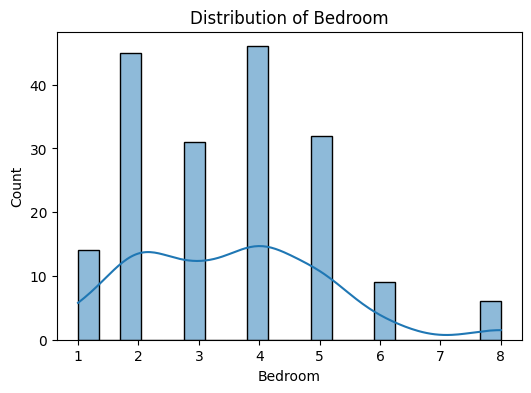

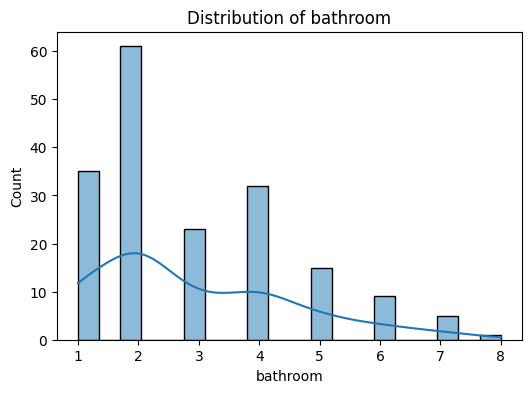

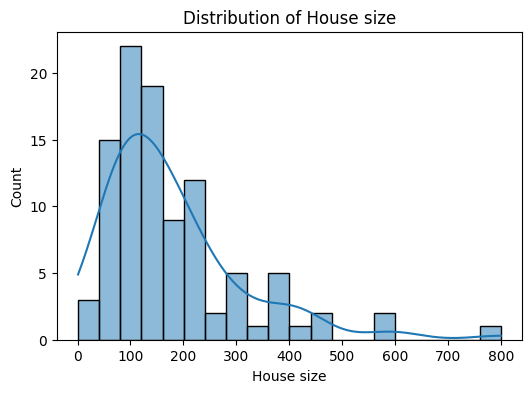

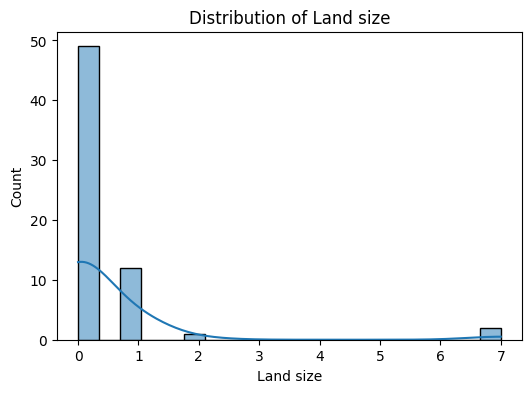

In [77]:
num_cols = ['Price', 'Bedroom', 'bathroom', 'House size', 'Land size']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()

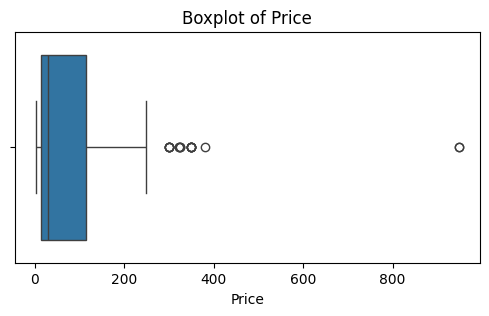

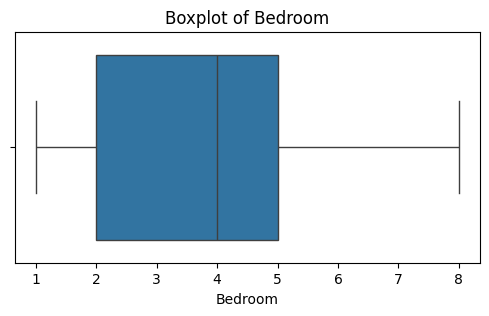

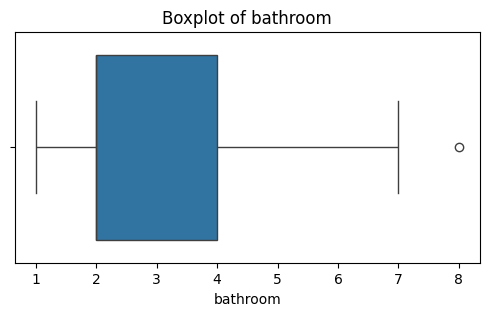

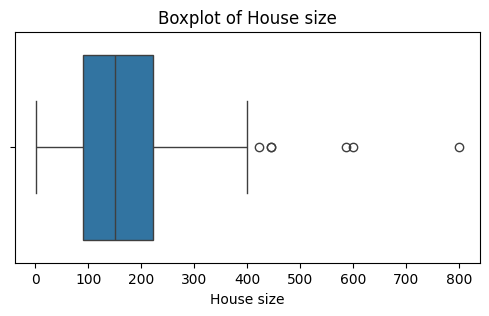

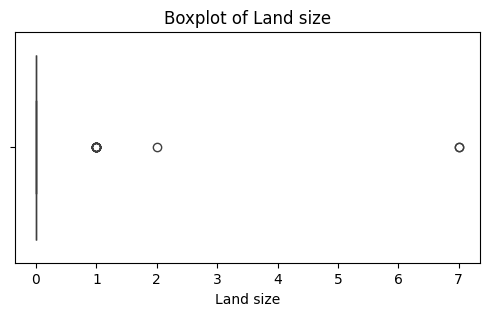

In [78]:
num_cols = ['Price', 'Bedroom', 'bathroom', 'House size', 'Land size']

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [79]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_1 = df[(df['Price'] >= lower) & (df['Price'] <= upper)]

In [81]:
df_1.info()

<class 'pandas.DataFrame'>
Index: 186 entries, 1 to 203
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         186 non-null    float64
 1   propertyType  186 non-null    str    
 2   Location      186 non-null    str    
 3   Bedroom       171 non-null    float64
 4   bathroom      169 non-null    float64
 5   House size    97 non-null     float64
 6   Land size     50 non-null     float64
dtypes: float64(5), str(2)
memory usage: 11.6 KB


In [83]:
df_1.isnull().sum()

Price             0
propertyType      0
Location          0
Bedroom          15
bathroom         17
House size       89
Land size       136
dtype: int64

In [84]:
df_1.isnull().sum()/len(df_1) * 100

Price            0.000000
propertyType     0.000000
Location         0.000000
Bedroom          8.064516
bathroom         9.139785
House size      47.849462
Land size       73.118280
dtype: float64

In [85]:
df_miss = df.copy()

df_miss['Bedroom_missing'] = df_miss['Bedroom'].isnull().astype(int)
df_miss['Bathroom_missing'] = df_miss['bathroom'].isnull().astype(int)
df_miss['House_size_missing'] = df_miss['House size'].isnull().astype(int)
df_miss['Land_size_missing'] = df_miss['Land size'].isnull().astype(int)

In [86]:
missing_by_type = df_miss.groupby('propertyType')[
    ['Bedroom_missing', 'Bathroom_missing', 'House_size_missing', 'Land_size_missing']
].mean()

missing_by_type

,Bedroom_missing,Bathroom_missing,House_size_missing,Land_size_missing
propertyType,,,,
Apartment,0.0,0.019231,0.269231,0.913462
Commercial Property,1.0,1.000000,1.000000,0.000000
Industrial Property,1.0,1.000000,1.000000,0.000000
Townhouse,0.0,0.000000,0.717949,0.538462
Townhuse,0.0,0.000000,1.000000,0.000000
Vacant Land,1.0,1.000000,0.947368,0.157895


In [87]:
df['propertyType'] = df['propertyType'].replace({'Townhuse': 'Townhouse'})

In [88]:
df['propertyType'].value_counts()

propertyType
Apartment              104
Townhouse               79
Vacant Land             19
Commercial Property      1
Industrial Property      1
Name: count, dtype: int64

In [89]:
df = df[~df["propertyType"].isin(["Commercial Property", "Industrial Property"])]

In [91]:
df['propertyType'].value_counts()

propertyType
Apartment      104
Townhouse       79
Vacant Land     19
Name: count, dtype: int64